In [1]:

#@title 1) Kurulum (~2-3 dk; derleme YOK, pytorch3d GEREKMEZ)
import os
if not os.path.exists('/content/MeshVTON'):
    !git clone https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git pull

# Yalnız eksik paketler (torch/transformers/accelerate Colab'da hazır):
!pip -q install "diffusers>=0.34" "peft>=0.14" lpips einops sentencepiece trimesh smplx pyrender onnxruntime
# OSMesa için pyrender'ın yamalı PyOpenGL fork'u ŞART (pip PyOpenGL'i
# "No array-type handler" ctypes hatası veriyor):
!pip -q uninstall -y pyopengl PyOpenGL-accelerate > /dev/null 2>&1
!pip -q install "git+https://github.com/mmatl/pyopengl.git"
# 4D-Humans (HMR2 — gerçek poz + pred_cam kamerası; kamera kapısı bunsuz çalışmaz)
import importlib.util
if importlib.util.find_spec('hmr2') is None:
    !pip -q install "git+https://github.com/shubham-goel/4D-Humans.git"
# GL sistem kütüphaneleri (Colab imajında libGLU yok -> pyrender import hatası)
!apt-get -qq install -y libglu1-mesa libosmesa6 > /dev/null 2>&1
# EGL çalışıyorsa onu, yoksa OSMesa'yı (yazılımsal, her yerde çalışır) kullan:
import subprocess
_probe = subprocess.run(["python", "-c",
    'import os;os.environ["PYOPENGL_PLATFORM"]="egl";'
    'import pyrender;r=pyrender.OffscreenRenderer(16,16);r.delete();print("egl-ok")'],
    capture_output=True, text=True)
os.environ['PYOPENGL_PLATFORM'] = 'egl' if 'egl-ok' in _probe.stdout else 'osmesa'
print('GL platform:', os.environ['PYOPENGL_PLATFORM'])

# IDM-VTON yalnız KIŞI ön-işlemesi için (parsing onnx + openpose ckpt); densepose/detectron2 YOK
if not os.path.exists('/content/IDM-VTON'):
    !git clone -q https://github.com/yisol/IDM-VTON /content/IDM-VTON
# Ön-işleme model dosyaları: wget DEĞİL hf_hub_download (LFS'i doğru indirir; wget
# HF'ten HTML hata sayfası kaydedip INVALID_PROTOBUF'a yol açabiliyor)
import shutil
from huggingface_hub import hf_hub_download
for repo_path in ('humanparsing/parsing_atr.onnx',
                  'humanparsing/parsing_lip.onnx',
                  'openpose/ckpts/body_pose_model.pth'):
    local = f'/content/IDM-VTON/ckpt/{repo_path}'
    if not (os.path.exists(local) and os.path.getsize(local) > 1_000_000):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        shutil.copy(hf_hub_download('yisol/IDM-VTON', repo_path), local)
    assert os.path.getsize(local) > 1_000_000, f'bozuk indirme: {local}'

# FLUX.1 dev gated: Colab Secrets'a HF_TOKEN ekleyin (soldaki anahtar simgesi, Notebook access açık)
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print('Kurulum OK')

Cloning into '/content/MeshVTON'...
remote: Enumerating objects: 964, done.
remote: Counting objects: 100% (471/471), done.
remote: Compressing objects: 100% (314/314), done.
remote: Total 964 (delta 303), reused 306 (delta 143), pack-reused 493 (from 1)
Receiving objects: 100% (964/964), 18.10 MiB | 33.58 MiB/s, done.
Resolving deltas: 100% (585/585), done.
/content/MeshVTON
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.2 MB/s eta 0:00:00
  Preparing

humanparsing/parsing_atr.onnx: reconstructing file:   0%|          |  0.00B /  267MB            

humanparsing/parsing_atr.onnx: downloading bytes:           |  0.00B            

humanparsing/parsing_lip.onnx: reconstructing file:   0%|          |  0.00B /  267MB            

humanparsing/parsing_lip.onnx: downloading bytes:           |  0.00B            

openpose/ckpts/body_pose_model.pth: reconstructing file:   0%|          |  0.00B /  209MB            

openpose/ckpts/body_pose_model.pth: downloading bytes:           |  0.00B            

Kurulum OK


In [2]:
#@title 2) Veri — Drive/MeshVTON düzenine göre (images.zip, garments_3d.zip, smplx/, smplx_params.zip)
import os, sys
sys.path.insert(0, '/content/MeshVTON/v2')
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/MeshVTON'

# zip'lerin İÇİNDE üst klasör var (images/, garments_3d/) -> bir üst hedefe aç:
!mkdir -p /content/MeshVTON/data/raw
!unzip -q -n $D/images.zip      -d /content/MeshVTON/data/raw    # -> data/raw/images/
!unzip -q -n $D/garments_3d.zip -d /content/MeshVTON/data        # -> data/garments_3d/

# SMPL-X modeli (Drive: MeshVTON/smplx/SMPLX_NEUTRAL.*) — 'checkpoints' klasörünü BİZ oluşturuyoruz,
# Drive'da olması gerekmiyor:
!mkdir -p /content/MeshVTON/checkpoints/pretrained/smplx
!cp $D/smplx/SMPLX_NEUTRAL.* /content/MeshVTON/checkpoints/pretrained/smplx/
os.environ['SMPLX_MODEL_DIR'] = '/content/MeshVTON/checkpoints/pretrained/smplx'

# Poz bankası: v1'in kişi başına SMPL-X tahminleri (sentetik veri gerçek pozlarla üretilsin)
!unzip -q -n $D/smplx_params.zip -d /content/MeshVTON/data/smplx_params

# HMR2 ağırlıkları (bir kez ~3.5GB) + SMPL neutral pkl (Drive: MeshVTON/smpl/)
import glob, shutil
from meshvton2.conditioning.body import _patch_torch_load_weights_only
import torch as _torch; _patch_torch_load_weights_only(_torch)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob(f'{D}/smpl/*neutral*lbs*.pkl') + glob.glob(f'{D}/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok -> Drive/MeshVTON/smpl/ (smplify.is.tue.mpg.de)"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")
print('HMR2 + SMPL hazır')

# doğrulama
!ls /content/MeshVTON/data/raw/images | head -3
!find /content/MeshVTON/data/garments_3d -name "*.obj" | wc -l
!ls /content/MeshVTON/checkpoints/pretrained/smplx
!ls /content/MeshVTON/data/smplx_params | head -3

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



Extracting file: hmr2_data.tar.gz
HMR2 + SMPL hazır
00000_00.jpg
00001_00.jpg
00002_00.jpg
1636
SMPLX_NEUTRAL.npz
00000_00.npz
00001_00.npz
00002_00.npz


In [3]:
!pip -q uninstall -y torchao
%cd /content/MeshVTON
!git pull

/content/MeshVTON
Already up to date.


In [4]:

#@title 3) TEK-KOŞU pipeline — Run all yeter; her aşama resume'ludur
NUM_SYNTH     = 2000   #@param {type:"integer"}   # tam üretim; duman için 5-50 kullanın
VITONHD_LIMIT = 2000   #@param {type:"integer"}
TRAIN_STEPS   = 6000  #@param {type:"integer"}
UNTIL         = "eval" #@param ["check","camera","smoke","synth","vitonhd","baseline","train","eval"]

# Colab koparsa: runtime'ı yeniden başlat -> Run all -> kaldığı yerden devam eder
# (sentetik üretim örnek sayısını sayar, eğitim latest.pt'den resume eder).
!python v2/scripts/colab_pipeline.py \
    --idm-repo /content/IDM-VTON \
    --num $NUM_SYNTH --vitonhd-limit $VITONHD_LIMIT --train-steps $TRAIN_STEPS \
    --until $UNTIL


== 1/8 ortam kontrolü
repo: cdee786 Update interactive_tryon.ipynb
GPU: NVIDIA A100-SXM4-80GB (85 GB)
bağımlılıklar tamam

== 2/8 kamera doğrulama kapısı (IoU >= 0.70)
$ python v2/scripts/build_golden_set.py --vitonhd-test /content/MeshVTON/data/raw/images --garments /content/MeshVTON/data/garments_3d
UYARI: --person-list verilmedi; eşit aralıklı otomatik seçim yapıldı.
Golden set poz çeşitliliği (yan/¾) ve VITON-dışı 2-3 foto için ELLE küratörlük ister:
  seçimi v2/configs/golden_persons.txt'e yazıp düzenleyin.
OK: 20 kişi × 5 giysi × 4 açı = 400 değerlendirme öğesi
Manifest: /content/MeshVTON/v2/data/golden/manifest.json (commit'lenir; görüntüler gitignored)
$ python v2/scripts/validate_camera.py --idm-repo /content/IDM-VTON --limit 5
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.l

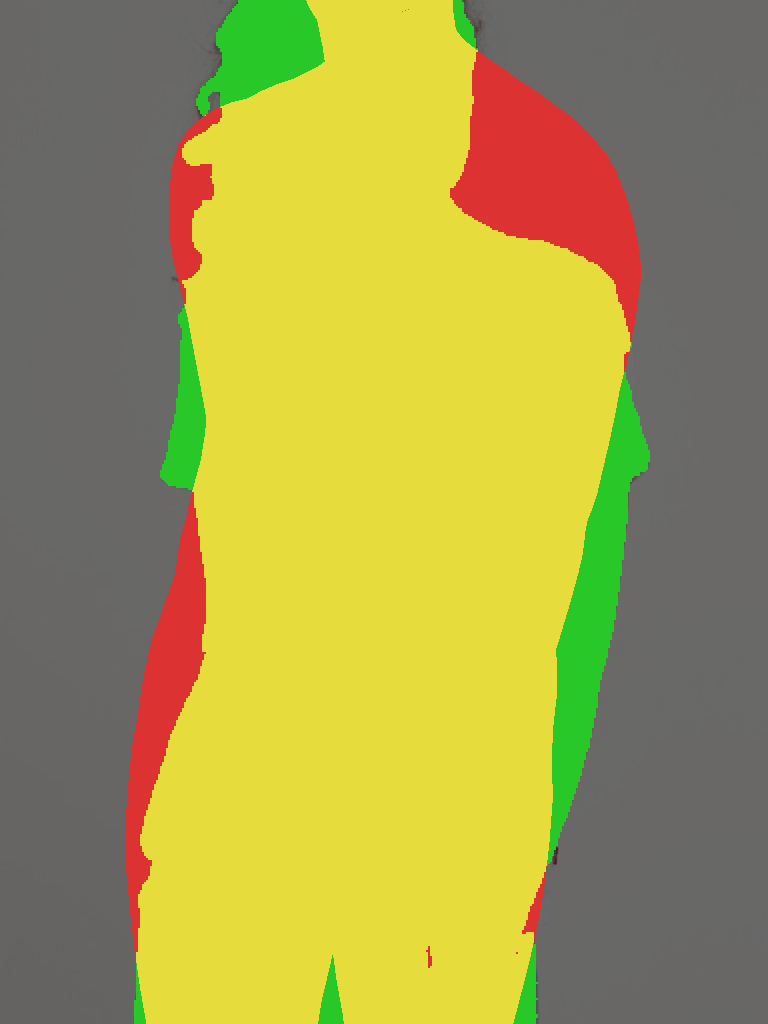

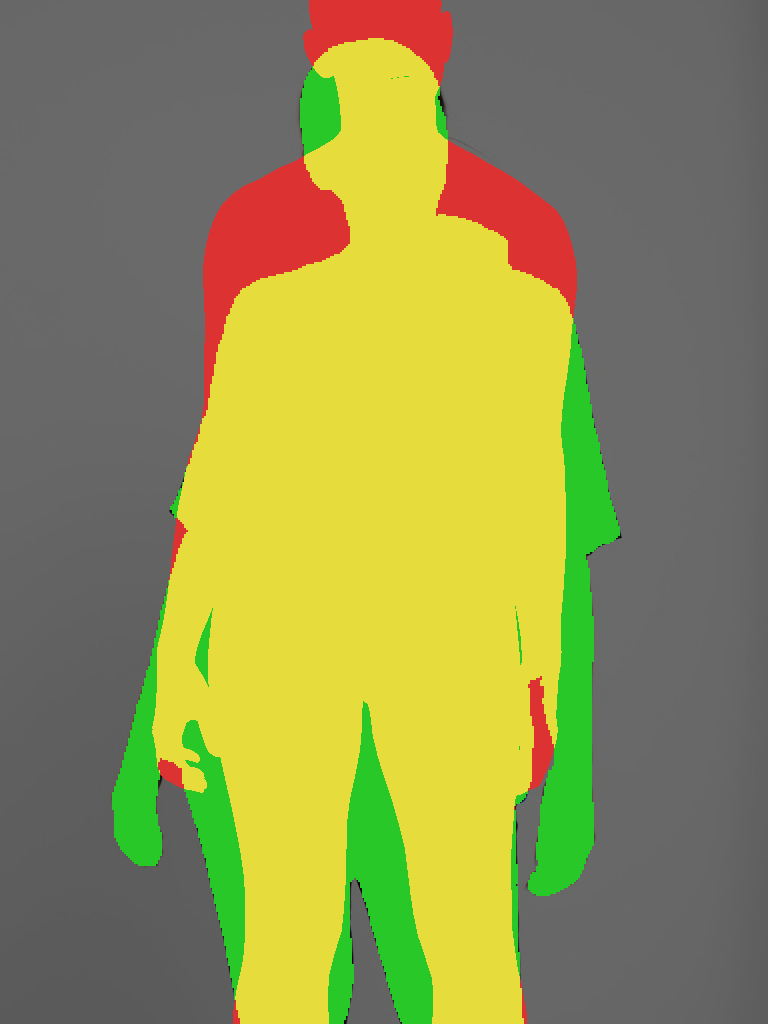

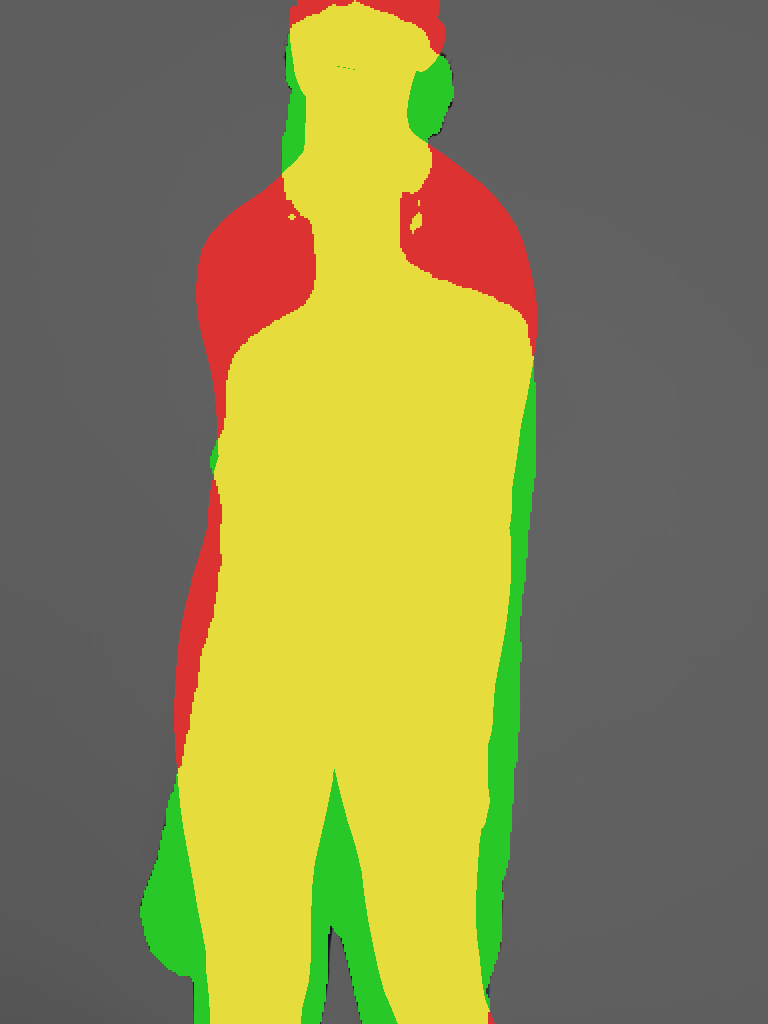

## Sentetik QA: s000_000000 (view_180 = arka görünüm mü?)

**0°**

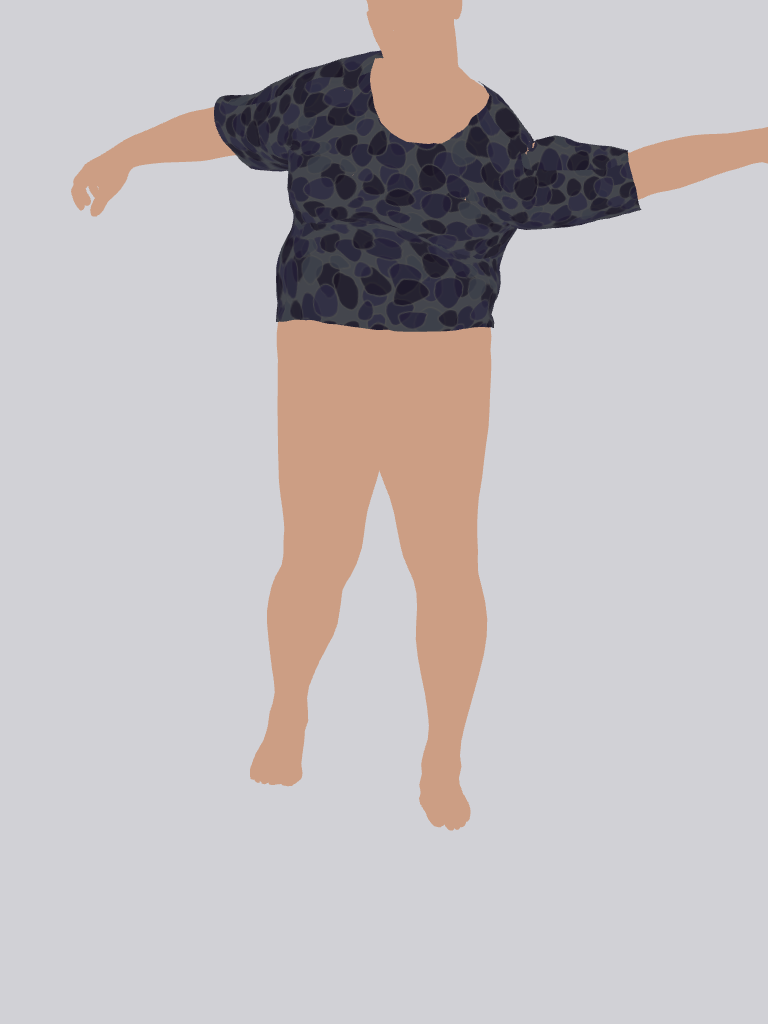

**90°**

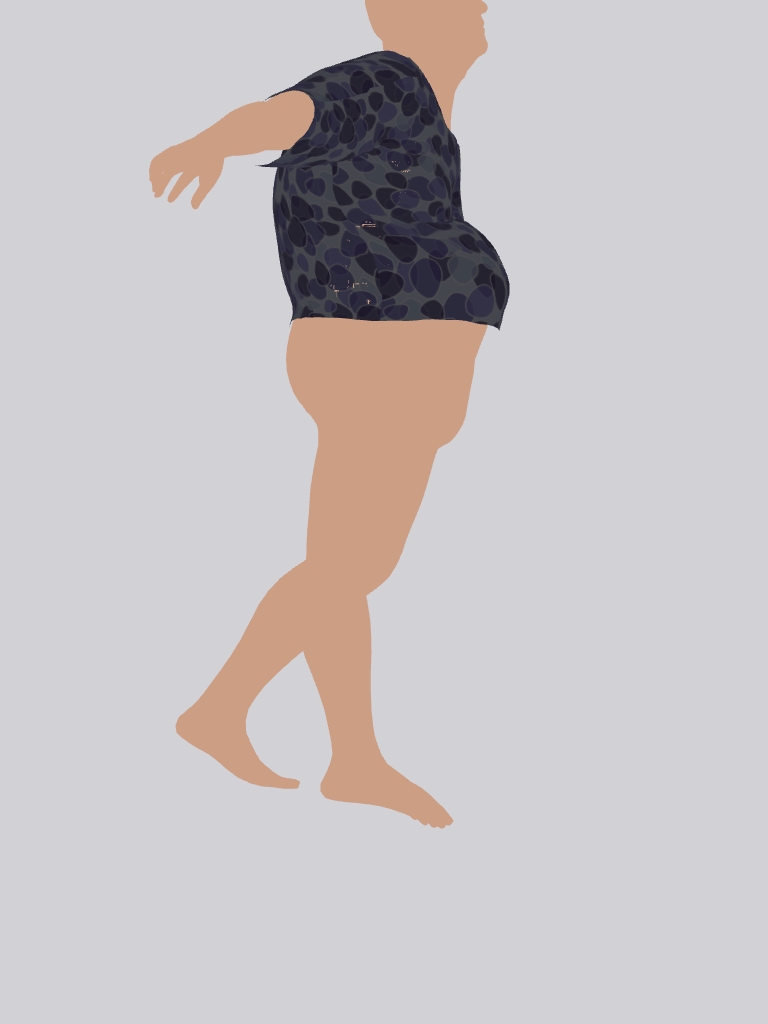

**180°**

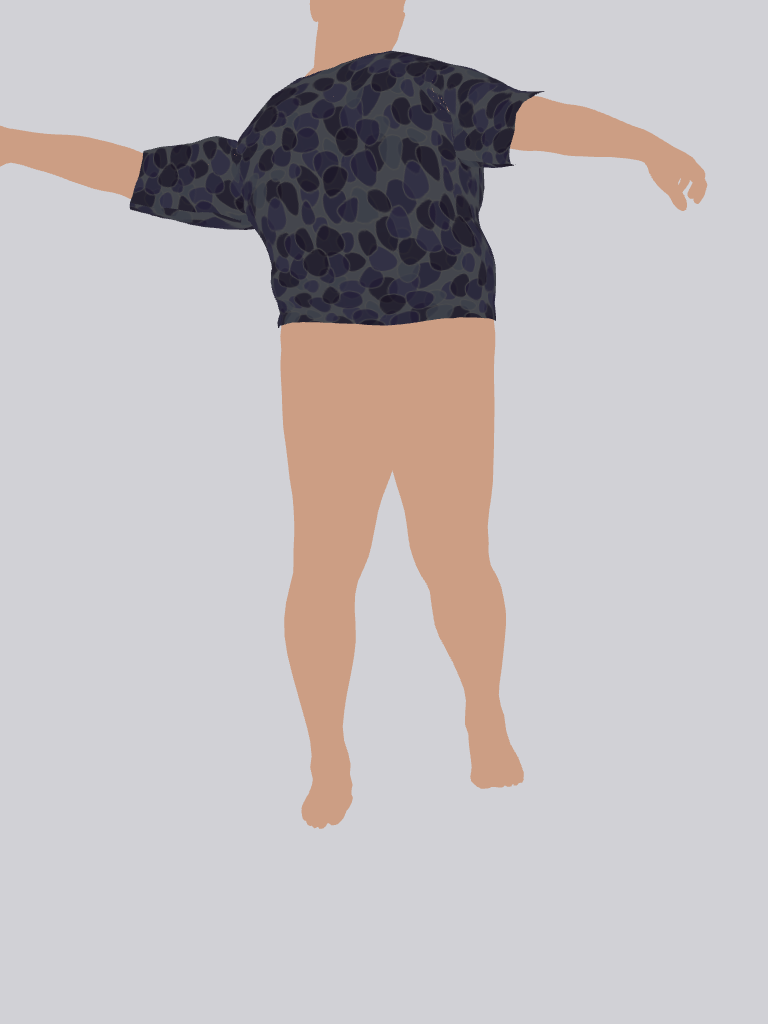

**270°**

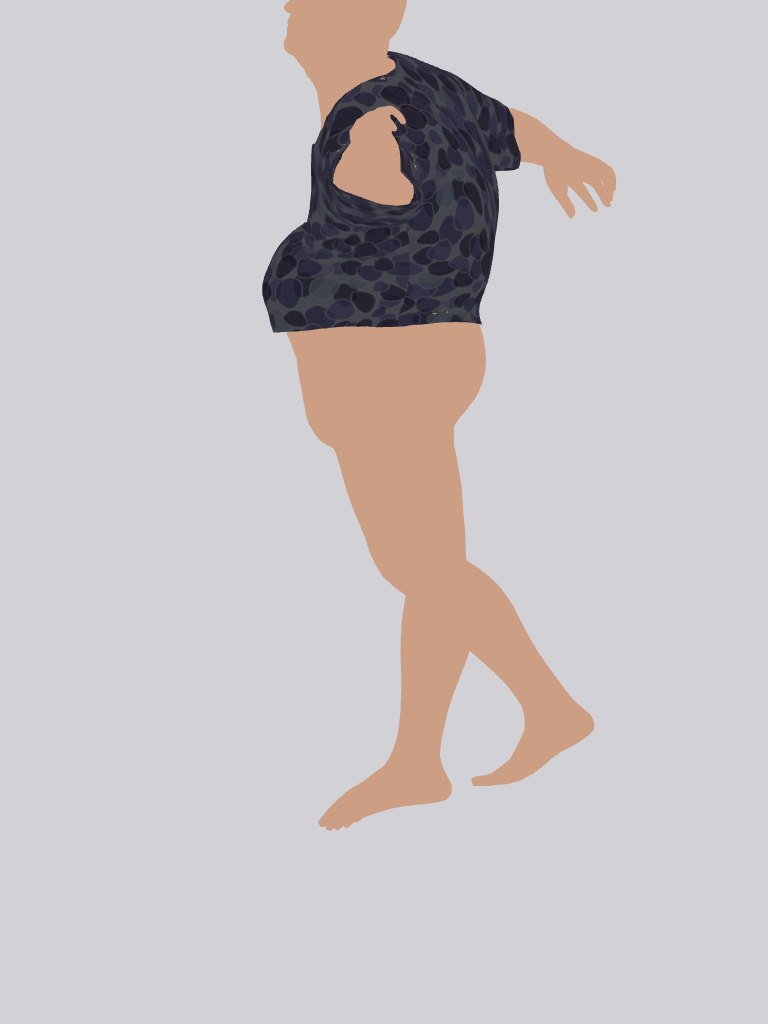

In [5]:

#@title 4) Sonuçlar (Drive: MeshVTON/v2_outputs altında da var)
from IPython.display import Image as I, display, Markdown
import pathlib

for md in sorted(pathlib.Path("v2/eval_results").glob("*.md")):
    display(Markdown(f"## {md.stem}"), Markdown(md.read_text()))
for grid in sorted(pathlib.Path("v2/eval_results").glob("*_grid.png")):
    display(I(str(grid), width=900))

# kamera doğrulama overlay'leri + sentetik QA
for f in sorted(pathlib.Path("v2/eval_results/camera_validation").glob("*.png"))[:3]:
    display(I(str(f), width=280))
qa = sorted(pathlib.Path("v2/eval_results/synth_qa").glob("s*/"))
if qa:
    s = qa[0]
    display(Markdown(f"## Sentetik QA: {s.name} (view_180 = arka görünüm mü?)"))
    for v in ("000", "090", "180", "270"):
        gt = s / f"view_{v}" / "gt.png"
        if gt.exists():
            display(Markdown(f"**{int(v)}°**"), I(str(gt), width=200))